## 1. Environment setup

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "imblearn": "imbalanced-learn",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "catboost": "catboost",
    "shap": "shap",
    "lime": "lime",
    "joblib": "joblib"
}

missing = []
for import_name, pip_name in required_packages.items():
    if importlib.util.find_spec(import_name) is None:
        missing.append(pip_name)

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are already available.")

All required packages are already available.


## 2. Imports and global configuration

In [3]:
import os
import json
import time
import math
import random
import shutil
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    average_precision_score, balanced_accuracy_score, matthews_corrcoef
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.validation import check_is_fitted

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap
import lime
import lime.lime_tabular
import joblib


SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

TARGET_COLUMN = "CARDIO_DISEASE"
PROJECT_NAME = "Shah_2025_Hybrid_Ensemble_XAI"

DATASET_DIR = Path("/kaggle/input/datasets/mohameddarweish/cardiovascular-diseases-processed-csv")

OUTPUT_DIR = Path("/kaggle/working/shah_2025_artifacts") if Path("/kaggle/working").exists() else Path("shah_2025_artifacts")
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
TABLE_DIR = OUTPUT_DIR / "tables"
XAI_DIR = OUTPUT_DIR / "xai_outputs"

for d in [OUTPUT_DIR, FIG_DIR, MODEL_DIR, TABLE_DIR, XAI_DIR]:
    d.mkdir(parents=True, exist_ok=True)


FAST_MODE = False    
XAI_SAMPLE_SIZE = 250 if not FAST_MODE else 100
SHAP_BACKGROUND_SIZE = 120 if not FAST_MODE else 50
PERMUTATION_SAMPLE_SIZE = 2500 if not FAST_MODE else 800
EMBEDDING_SAMPLE_SIZE = 2500 if not FAST_MODE else 800

print(f"Project: {PROJECT_NAME}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"FAST_MODE: {FAST_MODE}")

Project: Shah_2025_Hybrid_Ensemble_XAI
Output directory: /kaggle/working/shah_2025_artifacts
FAST_MODE: False


## 3. Dataset loading and utility helpers

In [4]:
def normalize_name(name):
    """Normalize column names to stable uppercase snake-case format."""
    name = str(name).strip().upper()
    for ch in [" ", "-", "/", "\\", ".", "(", ")", "%"]:
        name = name.replace(ch, "_")
    while "__" in name:
        name = name.replace("__", "_")
    return name.strip("_")


def save_fig(filename, dpi=160):
    """Save the current matplotlib figure to the figures directory."""
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path


def find_csv_files():
    """Find CSV files in the real Kaggle input path and safe fallback paths."""
    roots = [
        DATASET_DIR,
        Path("/kaggle/input"),
        Path("/content"),
        Path("."),
    ]
    candidates = []
    for root in roots:
        if root.exists():
            candidates.extend(list(root.rglob("*.csv")))
    seen = set()
    unique = []
    for p in candidates:
        rp = str(p.resolve())
        if rp not in seen:
            seen.add(rp)
            unique.append(p)
    return unique


def choose_dataset_path(csv_files):
    """Prefer a cardiovascular/cardio processed CSV if multiple files exist."""
    if not csv_files:
        return None
    def score(path):
        name = path.name.lower()
        s = 0
        keywords = ["cardiovascular", "cardio", "heart", "processed", "disease"]
        for kw in keywords:
            if kw in name or kw in str(path).lower():
                s += 10
        try:
            s += min(path.stat().st_size / 1e6, 50)
        except Exception:
            pass
        return s
    return sorted(csv_files, key=score, reverse=True)[0]

csv_files = find_csv_files()
print("CSV candidates found:")
for p in csv_files[:20]:
    print(" -", p)

DATA_PATH = Path(os.environ.get("DATA_PATH", "")) if os.environ.get("DATA_PATH") else choose_dataset_path(csv_files)
if DATA_PATH is None or not Path(DATA_PATH).exists():
    raise FileNotFoundError(
        "No CSV dataset was found. Please attach the dataset to Kaggle or set DATA_PATH to the CSV path."
    )

print(f"\nSelected dataset path: {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw dataset shape: {df_raw.shape}")
display(df_raw.head())

CSV candidates found:
 - /kaggle/input/datasets/mohameddarweish/cardiovascular-diseases-processed-csv/cardiovascular_diseases_processed.csv
 - /content/sample_data/mnist_train_small.csv
 - /content/sample_data/california_housing_train.csv
 - /content/sample_data/california_housing_test.csv
 - /content/sample_data/mnist_test.csv

Selected dataset path: /kaggle/input/datasets/mohameddarweish/cardiovascular-diseases-processed-csv/cardiovascular_diseases_processed.csv
Raw dataset shape: (68783, 12)


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE
0,50,2,168,62,110,80,1,1,0,0,1,0
1,55,1,156,85,140,90,3,1,0,0,1,1
2,52,1,165,64,130,70,3,1,0,0,0,1
3,48,2,169,82,150,100,1,1,0,0,1,1
4,48,1,156,56,100,60,1,1,0,0,0,0


## 4. Column cleaning, target detection, and data audit

In [5]:
df = df_raw.copy()
df.columns = [normalize_name(c) for c in df.columns]

unnamed_cols = [c for c in df.columns if c.startswith("UNNAMED") or c in ["INDEX"]]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)
    print("Dropped index-like columns:", unnamed_cols)

target_candidates = [
    TARGET_COLUMN,
    "CARDIO_DISEASE", "CARDIO", "TARGET", "OUTPUT", "TENYEARCHD",
    "HEARTDISEASE", "HEART_DISEASE", "DISEASE", "NUM", "CLASS", "LABEL"
]

target_col = None
for candidate in target_candidates:
    candidate_norm = normalize_name(candidate)
    if candidate_norm in df.columns:
        target_col = candidate_norm
        break

if target_col is None:
    binary_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 2]
    disease_like = [c for c in binary_cols if any(k in c for k in ["CARDIO", "HEART", "DISEASE", "TARGET", "CLASS", "LABEL"])]
    if disease_like:
        target_col = disease_like[0]

if target_col is None:
    raise ValueError(f"Could not detect target column. Available columns: {df.columns.tolist()}")

if target_col != TARGET_COLUMN:
    df = df.rename(columns={target_col: TARGET_COLUMN})
    target_col = TARGET_COLUMN

if not pd.api.types.is_numeric_dtype(df[TARGET_COLUMN]):
    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str).str.strip().str.upper()
    positive_values = {"1", "YES", "Y", "TRUE", "DISEASE", "POSITIVE", "PRESENT"}
    df[TARGET_COLUMN] = df[TARGET_COLUMN].apply(lambda x: 1 if x in positive_values else 0)
else:
    unique_vals = sorted(pd.Series(df[TARGET_COLUMN].dropna().unique()).tolist())
    if len(unique_vals) > 2:
        print("Target appears multiclass; mapping values > 0 to 1.")
        df[TARGET_COLUMN] = (df[TARGET_COLUMN] > 0).astype(int)
    else:
        df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

duplicates_before = df.duplicated().sum()
if duplicates_before > 0:
    print(f"Duplicate rows found: {duplicates_before}. Dropping duplicates.")
    df = df.drop_duplicates().reset_index(drop=True)

print("Cleaned columns:")
print(df.columns.tolist())
print(f"\nCleaned dataset shape: {df.shape}")
print("\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts())
print("\nTarget distribution ratio:")
print(df[TARGET_COLUMN].value_counts(normalize=True))

schema_df = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_count": [int(df[c].isna().sum()) for c in df.columns],
    "unique_count": [int(df[c].nunique(dropna=True)) for c in df.columns]
})
schema_df.to_csv(TABLE_DIR / "dataset_schema.csv", index=False)
display(schema_df)

Duplicate rows found: 3820. Dropping duplicates.
Cleaned columns:
['AGE', 'GENDER', 'HEIGHT', 'WEIGHT', 'AP_HIGH', 'AP_LOW', 'CHOLESTEROL', 'GLUCOSE', 'SMOKE', 'ALCOHOL', 'PHYSICAL_ACTIVITY', 'CARDIO_DISEASE']

Cleaned dataset shape: (64963, 12)

Target distribution:
CARDIO_DISEASE
1    33053
0    31910
Name: count, dtype: int64

Target distribution ratio:
CARDIO_DISEASE
1    0.508797
0    0.491203
Name: proportion, dtype: float64


,column,dtype,missing_count,unique_count
0,AGE,int64,0,28
1,GENDER,int64,0,2
2,HEIGHT,int64,0,106
3,WEIGHT,int64,0,152
4,AP_HIGH,int64,0,108
5,AP_LOW,int64,0,84
6,CHOLESTEROL,int64,0,3
7,GLUCOSE,int64,0,3
8,SMOKE,int64,0,2
9,ALCOHOL,int64,0,2


## 5. Exploratory Data Analysis (EDA)

In [6]:
print("=" * 90)
print("DATASET OVERVIEW")
print("=" * 90)
print(f"Dataset shape: {df.shape}")
print(f"Number of features excluding target: {df.shape[1] - 1}")
print(f"Missing values: {int(df.isna().sum().sum())}")
print(f"Duplicate rows after cleaning: {int(df.duplicated().sum())}")

summary_stats = df.describe(include="all").T
summary_stats.to_csv(TABLE_DIR / "summary_statistics.csv")

class_distribution = df[TARGET_COLUMN].value_counts().rename_axis("class").reset_index(name="count")
class_distribution["percentage"] = class_distribution["count"] / class_distribution["count"].sum() * 100
class_distribution.to_csv(TABLE_DIR / "class_distribution.csv", index=False)

display(summary_stats.head(20))
display(class_distribution)

DATASET OVERVIEW
Dataset shape: (64963, 12)
Number of features excluding target: 11
Missing values: 0
Duplicate rows after cleaning: 0


,count,mean,std,min,25%,50%,75%,max
AGE,64963.0,53.353155,6.811546,30.0,48.0,54.0,59.0,65.0
GENDER,64963.0,1.356511,0.478972,1.0,1.0,1.0,2.0,2.0
HEIGHT,64963.0,164.347259,8.330184,55.0,159.0,165.0,170.0,250.0
WEIGHT,64963.0,74.497252,14.552793,11.0,65.0,72.0,82.5,200.0
AP_HIGH,64963.0,126.979989,17.116092,60.0,120.0,120.0,140.0,240.0
AP_LOW,64963.0,81.480766,9.904148,40.0,80.0,80.0,90.0,190.0
CHOLESTEROL,64963.0,1.384080,0.691197,1.0,1.0,1.0,2.0,3.0
GLUCOSE,64963.0,1.237905,0.584059,1.0,1.0,1.0,1.0,3.0
SMOKE,64963.0,0.092714,0.290034,0.0,0.0,0.0,0.0,1.0
ALCOHOL,64963.0,0.056663,0.231199,0.0,0.0,0.0,0.0,1.0


,class,count,percentage
0,1,33053,50.879732
1,0,31910,49.120268


Saved figure: /kaggle/working/shah_2025_artifacts/figures/eda_class_distribution.png


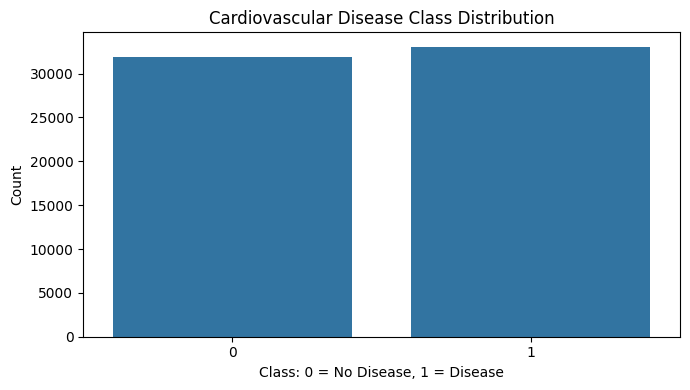

Saved figure: /kaggle/working/shah_2025_artifacts/figures/eda_numeric_distributions.png


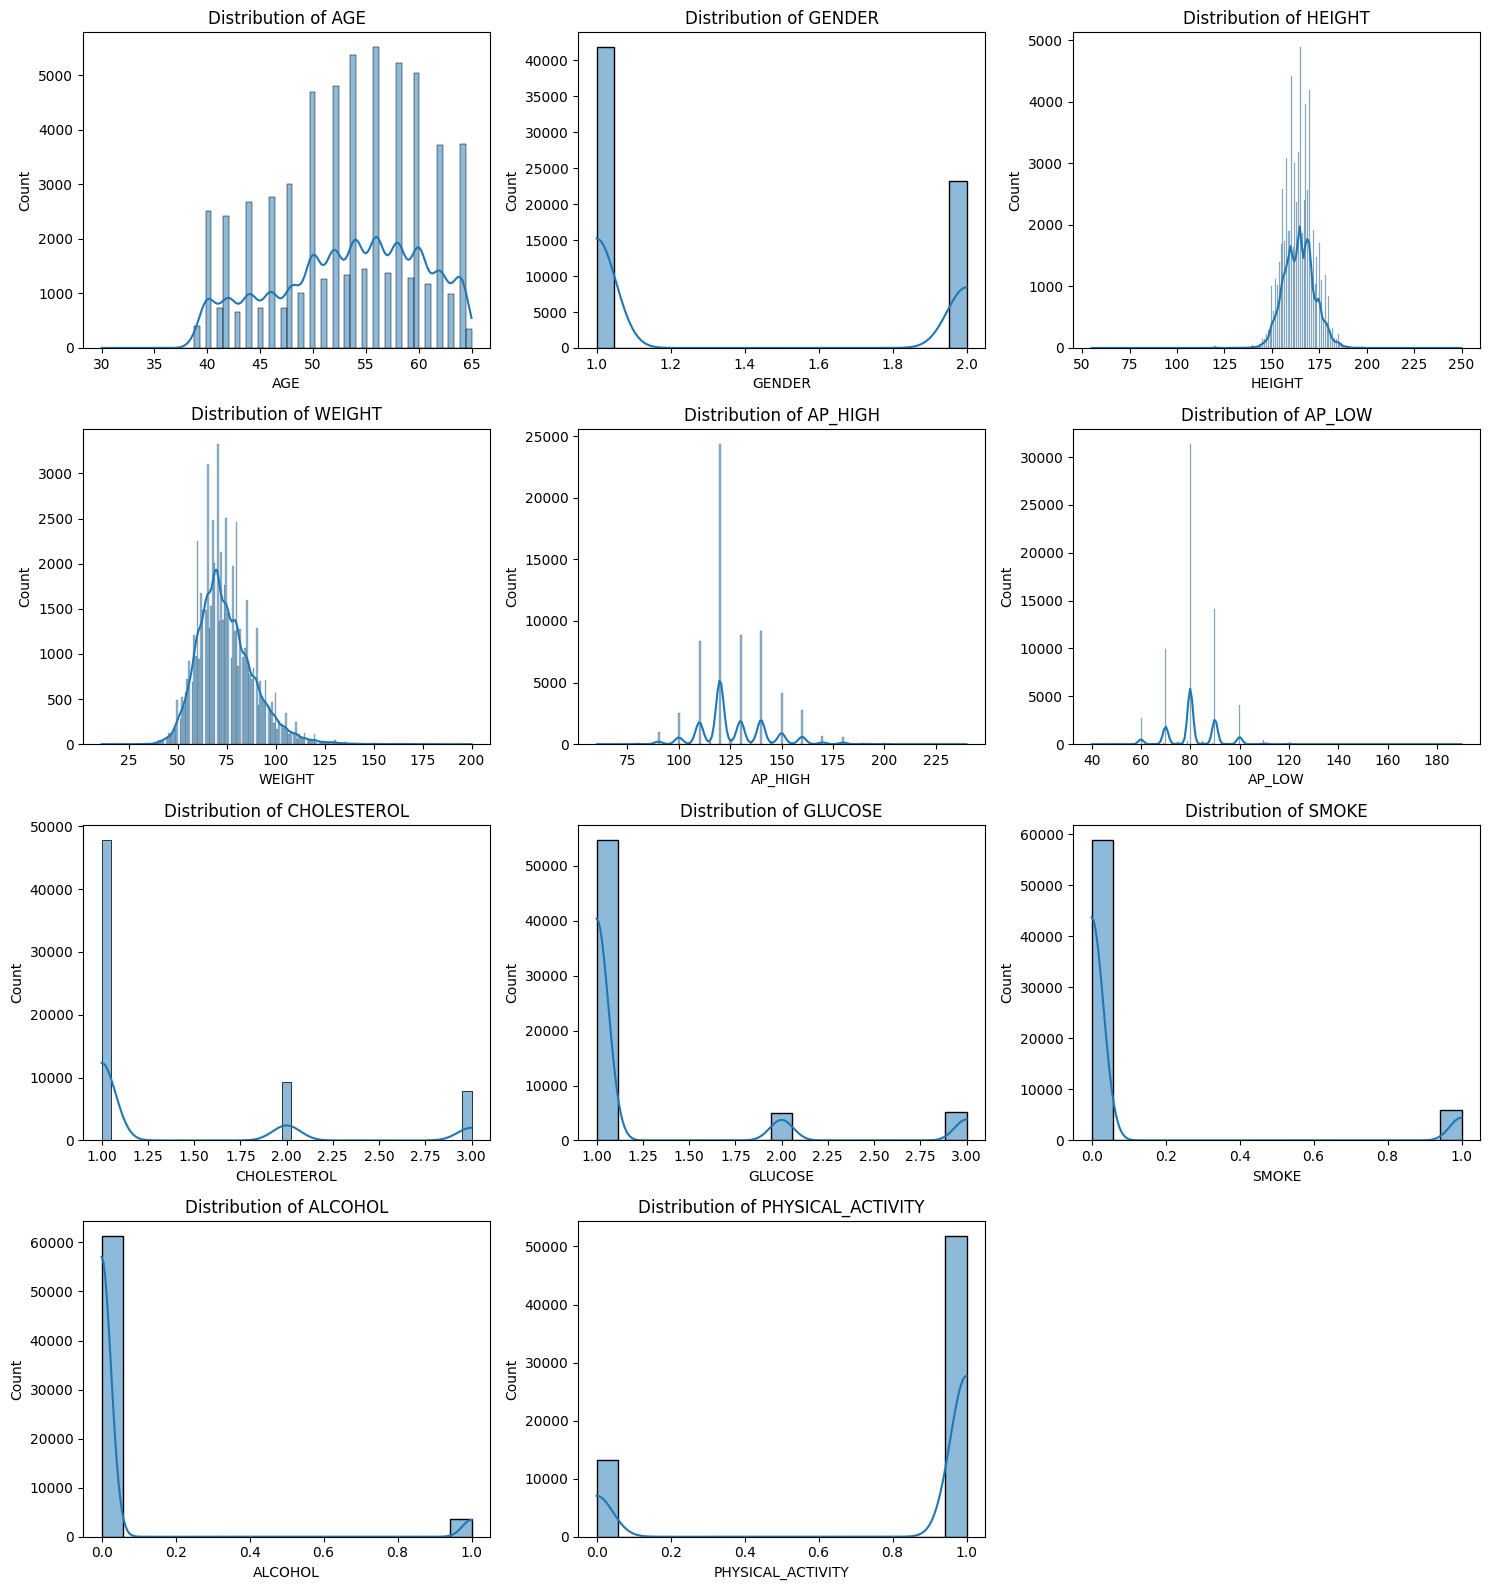

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=TARGET_COLUMN)
plt.title("Cardiovascular Disease Class Distribution")
plt.xlabel("Class: 0 = No Disease, 1 = Disease")
plt.ylabel("Count")
save_fig("eda_class_distribution.png")
plt.show()

numeric_cols = [c for c in df.columns if c != TARGET_COLUMN and pd.api.types.is_numeric_dtype(df[c])]
plot_cols = numeric_cols[:12]

if plot_cols:
    n_cols = 3
    n_rows = math.ceil(len(plot_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, plot_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=ax)
        ax.set_title(f"Distribution of {col}")
    for ax in axes[len(plot_cols):]:
        ax.axis("off")
    save_fig("eda_numeric_distributions.png")
    plt.show()
else:
    print("No numeric columns found for histograms.")

Saved figure: /kaggle/working/shah_2025_artifacts/figures/eda_correlation_heatmap.png


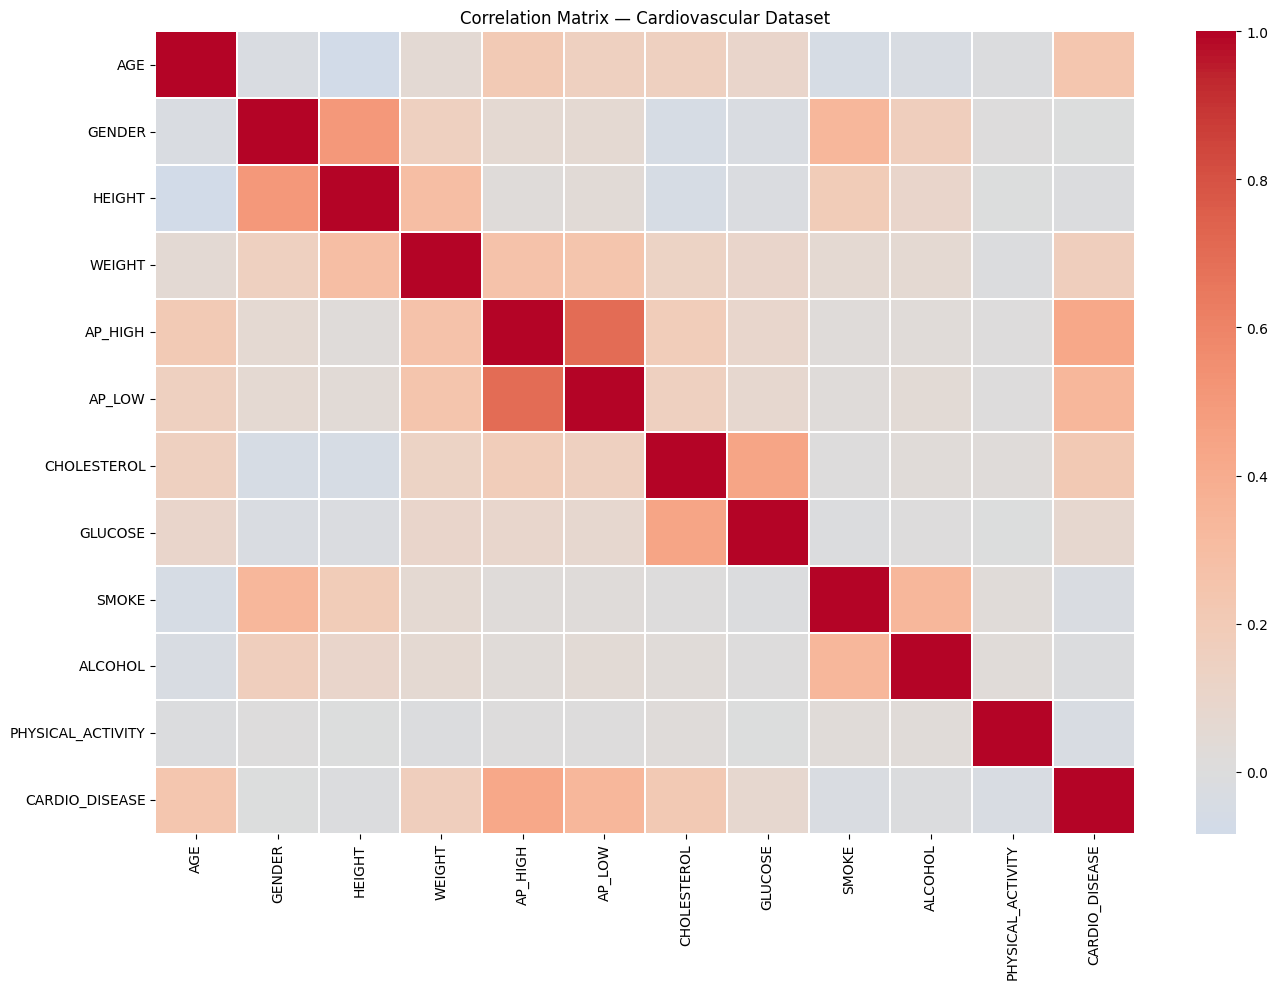

Top absolute correlations with target:


,correlation_with_target
AP_HIGH,0.423504
AP_LOW,0.335708
AGE,0.235642
CHOLESTEROL,0.213521
WEIGHT,0.172617
GLUCOSE,0.081323
PHYSICAL_ACTIVITY,-0.028717
SMOKE,-0.024470
ALCOHOL,-0.015167
HEIGHT,-0.009193


In [8]:
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] > 1:
    corr = numeric_df.corr(numeric_only=True)
    corr.to_csv(TABLE_DIR / "correlation_matrix.csv")
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
    plt.title("Correlation Matrix — Cardiovascular Dataset")
    save_fig("eda_correlation_heatmap.png")
    plt.show()

    target_corr = corr[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=np.abs, ascending=False)
    target_corr.to_csv(TABLE_DIR / "target_correlations.csv")
    print("Top absolute correlations with target:")
    display(target_corr.head(15).to_frame("correlation_with_target"))
else:
    print("Not enough numeric features for correlation analysis.")

## 6. Clinical feature engineering

In [9]:
df_fe = df.copy()

def has_cols(*cols):
    return all(c in df_fe.columns for c in cols)

if "AGE" in df_fe.columns:
    if pd.to_numeric(df_fe["AGE"], errors="coerce").max() > 150:
        df_fe["AGE_YEARS"] = df_fe["AGE"] / 365.25
    else:
        df_fe["AGE_YEARS"] = df_fe["AGE"]

if has_cols("WEIGHT", "HEIGHT"):
    height_m = df_fe["HEIGHT"].replace(0, np.nan) / 100.0
    df_fe["BMI"] = df_fe["WEIGHT"] / (height_m ** 2)
    df_fe["BMI"] = df_fe["BMI"].replace([np.inf, -np.inf], np.nan)
    df_fe["BMI_CATEGORY_OBESE"] = (df_fe["BMI"] >= 30).astype(int)
    df_fe["BMI_CATEGORY_OVERWEIGHT"] = (df_fe["BMI"] >= 25).astype(int)

if has_cols("AP_HIGH", "AP_LOW"):
    df_fe["PULSE_PRESSURE"] = df_fe["AP_HIGH"] - df_fe["AP_LOW"]
    df_fe["MAP_ESTIMATE"] = df_fe["AP_LOW"] + (df_fe["PULSE_PRESSURE"] / 3.0)
    df_fe["BP_RATIO"] = df_fe["AP_HIGH"] / (df_fe["AP_LOW"].replace(0, np.nan))
    df_fe["HYPERTENSION_FLAG"] = ((df_fe["AP_HIGH"] >= 140) | (df_fe["AP_LOW"] >= 90)).astype(int)
    df_fe["LOW_BP_FLAG"] = ((df_fe["AP_HIGH"] < 90) | (df_fe["AP_LOW"] < 60)).astype(int)

if has_cols("CHOLESTEROL", "GLUCOSE"):
    df_fe["CHOL_GLUCOSE_RATIO"] = df_fe["CHOLESTEROL"] / (df_fe["GLUCOSE"].replace(0, np.nan))
    df_fe["HIGH_CHOL_HIGH_GLUCOSE"] = ((df_fe["CHOLESTEROL"] > 1) & (df_fe["GLUCOSE"] > 1)).astype(int)

if has_cols("AGE_YEARS", "BMI"):
    df_fe["AGE_BMI_INTERACTION"] = df_fe["AGE_YEARS"] * df_fe["BMI"]
if has_cols("AGE_YEARS", "AP_HIGH"):
    df_fe["AGE_SBP_INTERACTION"] = df_fe["AGE_YEARS"] * df_fe["AP_HIGH"]
if has_cols("AP_HIGH", "CHOLESTEROL"):
    df_fe["SBP_CHOLESTEROL_INTERACTION"] = df_fe["AP_HIGH"] * df_fe["CHOLESTEROL"]

df_fe = df_fe.replace([np.inf, -np.inf], np.nan)

engineered_columns = [c for c in df_fe.columns if c not in df.columns]
print(f"Original columns: {df.shape[1]}")
print(f"Columns after feature engineering: {df_fe.shape[1]}")
print("Engineered columns:", engineered_columns)

pd.DataFrame({"engineered_feature": engineered_columns}).to_csv(TABLE_DIR / "engineered_features.csv", index=False)
display(df_fe.head())

Original columns: 12
Columns after feature engineering: 26
Engineered columns: ['AGE_YEARS', 'BMI', 'BMI_CATEGORY_OBESE', 'BMI_CATEGORY_OVERWEIGHT', 'PULSE_PRESSURE', 'MAP_ESTIMATE', 'BP_RATIO', 'HYPERTENSION_FLAG', 'LOW_BP_FLAG', 'CHOL_GLUCOSE_RATIO', 'HIGH_CHOL_HIGH_GLUCOSE', 'AGE_BMI_INTERACTION', 'AGE_SBP_INTERACTION', 'SBP_CHOLESTEROL_INTERACTION']


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,...,PULSE_PRESSURE,MAP_ESTIMATE,BP_RATIO,HYPERTENSION_FLAG,LOW_BP_FLAG,CHOL_GLUCOSE_RATIO,HIGH_CHOL_HIGH_GLUCOSE,AGE_BMI_INTERACTION,AGE_SBP_INTERACTION,SBP_CHOLESTEROL_INTERACTION
0,50,2,168,62,110,80,1,1,0,0,...,30,90.000000,1.375000,0,0,1.0,0,1098.356009,5500,110
1,55,1,156,85,140,90,3,1,0,0,...,50,106.666667,1.555556,1,0,3.0,0,1921.022354,7700,420
2,52,1,165,64,130,70,3,1,0,0,...,60,90.000000,1.857143,0,0,3.0,0,1222.405877,6760,390
3,48,2,169,82,150,100,1,1,0,0,...,50,116.666667,1.500000,1,0,1.0,0,1378.103008,7200,150
4,48,1,156,56,100,60,1,1,0,0,...,40,73.333333,1.666667,0,0,1.0,0,1104.536489,4800,100


## 7. Train/test split and preprocessing

In [10]:
df_model = df_fe.copy()

id_like_cols = [c for c in df_model.columns if c != TARGET_COLUMN and c in ["ID", "PATIENT_ID", "ROW_ID"]]
if id_like_cols:
    df_model = df_model.drop(columns=id_like_cols)
    print("Dropped ID-like columns:", id_like_cols)

X = df_model.drop(columns=[TARGET_COLUMN])
y = df_model[TARGET_COLUMN].astype(int)

numeric_features = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
categorical_features = [c for c in X.columns if c not in numeric_features]

print(f"Number of numeric features: {len(numeric_features)}")
print(f"Number of categorical features: {len(categorical_features)}")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out().tolist()
X_train = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train_raw.index)
X_test = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test_raw.index)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("Training target distribution:")
print(y_train.value_counts())
print("Testing target distribution:")
print(y_test.value_counts())

pd.Series(feature_names, name="feature").to_csv(TABLE_DIR / "final_feature_names.csv", index=False)

Number of numeric features: 25
Number of categorical features: 0
X_train shape: (51970, 25)
X_test shape: (12993, 25)
Training target distribution:
CARDIO_DISEASE
1    26442
0    25528
Name: count, dtype: int64
Testing target distribution:
CARDIO_DISEASE
1    6611
0    6382
Name: count, dtype: int64


## 8. Imbalance handling: SMOTE + undersampling

In [11]:
print("Original training class distribution:")
print(y_train.value_counts())

try:
    class_counts = y_train.value_counts()
    minority_count = int(class_counts.min())
    if minority_count >= 6:
        smote = SMOTE(random_state=SEED, k_neighbors=min(5, minority_count - 1), sampling_strategy=0.85)
        X_smote, y_smote = smote.fit_resample(X_train, y_train)
        under = RandomUnderSampler(random_state=SEED, sampling_strategy=1.0)
        X_train_balanced, y_train_balanced = under.fit_resample(X_smote, y_smote)
        balancing_method = "SMOTE + RandomUnderSampler"
    else:
        ros = RandomOverSampler(random_state=SEED)
        X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)
        balancing_method = "RandomOverSampler fallback"
except Exception as e:
    print("Balancing failed; using unbalanced training data. Error:", repr(e))
    X_train_balanced, y_train_balanced = X_train.copy(), y_train.copy()
    balancing_method = "No balancing fallback"

X_train_balanced = pd.DataFrame(X_train_balanced, columns=feature_names)
y_train_balanced = pd.Series(y_train_balanced, name=TARGET_COLUMN)

print(f"Balancing method: {balancing_method}")
print("Balanced training class distribution:")
print(y_train_balanced.value_counts())
print(f"Balanced training shape: {X_train_balanced.shape}")

pd.DataFrame({
    "class": y_train_balanced.value_counts().index,
    "count": y_train_balanced.value_counts().values
}).to_csv(TABLE_DIR / "balanced_class_distribution.csv", index=False)

Original training class distribution:
CARDIO_DISEASE
1    26442
0    25528
Name: count, dtype: int64
Balancing failed; using unbalanced training data. Error: ValueError('The specified ratio required to remove samples from the minority class while trying to generate new samples. Please increase the ratio.')
Balancing method: No balancing fallback
Balanced training class distribution:
CARDIO_DISEASE
1    26442
0    25528
Name: count, dtype: int64
Balanced training shape: (51970, 25)


## 9. Shah-style hybrid stacked ensemble model

In [12]:
n_estimators = 220 if not FAST_MODE else 80
mlp_iter = 260 if not FAST_MODE else 120
stack_cv_folds = 3

base_models = {
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=0.045,
        max_depth=3,
        subsample=0.85,
        random_state=SEED
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=0.045,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=SEED,
        verbosity=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=n_estimators,
        depth=6,
        learning_rate=0.045,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=SEED,
        verbose=0
    ),
    "CalibratedLinearSVM": CalibratedClassifierCV(
        estimator=LinearSVC(C=1.0, random_state=SEED, max_iter=5000),
        method="sigmoid",
        cv=3
    ),
    "NeuralNetwork_MLP": MLPClassifier(
        hidden_layer_sizes=(96, 48),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=0.001,
        max_iter=mlp_iter,
        early_stopping=True,
        random_state=SEED
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1
    ),
}

meta_learner = XGBClassifier(
    n_estimators=260 if not FAST_MODE else 100,
    max_depth=3,
    learning_rate=0.035,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1
)

stacking_model = StackingClassifier(
    estimators=[(name, clone(model)) for name, model in base_models.items()],
    final_estimator=meta_learner,
    stack_method="predict_proba",
    passthrough=True,
    cv=StratifiedKFold(n_splits=stack_cv_folds, shuffle=True, random_state=SEED),
    n_jobs=-1
)

print("Base models:")
for name in base_models:
    print(" -", name)
print("Meta-learner: XGBoost")
print("Stacking passthrough: True, so the meta-learner sees base predictions + original features.")

Base models:
 - GradientBoosting
 - LightGBM
 - CatBoost
 - CalibratedLinearSVM
 - NeuralNetwork_MLP
 - RandomForest
Meta-learner: XGBoost
Stacking passthrough: True, so the meta-learner sees base predictions + original features.


## 10. Model training

In [13]:
trained_models = {}
training_times = []

for name, model in base_models.items():
    print("=" * 90)
    print(f"Training base model: {name}")
    start = time.time()
    fitted = clone(model)
    fitted.fit(X_train_balanced, y_train_balanced)
    elapsed = time.time() - start
    trained_models[name] = fitted
    training_times.append({"model": name, "training_seconds": elapsed})
    print(f"Finished {name} in {elapsed:.2f} seconds")

print("=" * 90)
print("Training Shah-style Hybrid Stacked Ensemble...")
start = time.time()
best_full_model = stacking_model
best_full_model.fit(X_train_balanced, y_train_balanced)
elapsed = time.time() - start
trained_models["Shah_Hybrid_Stacked_Ensemble"] = best_full_model
training_times.append({"model": "Shah_Hybrid_Stacked_Ensemble", "training_seconds": elapsed})
print(f"Finished Hybrid Stacked Ensemble in {elapsed:.2f} seconds")

training_times_df = pd.DataFrame(training_times)
training_times_df.to_csv(TABLE_DIR / "training_times.csv", index=False)
display(training_times_df)

Training base model: GradientBoosting
Finished GradientBoosting in 19.19 seconds
Training base model: LightGBM
Finished LightGBM in 0.96 seconds
Training base model: CatBoost
Finished CatBoost in 2.23 seconds
Training base model: CalibratedLinearSVM
Finished CalibratedLinearSVM in 1.23 seconds
Training base model: NeuralNetwork_MLP
Finished NeuralNetwork_MLP in 4.39 seconds
Training base model: RandomForest
Finished RandomForest in 9.54 seconds
Training Shah-style Hybrid Stacked Ensemble...
Finished Hybrid Stacked Ensemble in 86.41 seconds


,model,training_seconds
0,GradientBoosting,19.190861
1,LightGBM,0.956884
2,CatBoost,2.231763
3,CalibratedLinearSVM,1.229351
4,NeuralNetwork_MLP,4.393860
5,RandomForest,9.539795
6,Shah_Hybrid_Stacked_Ensemble,86.412815


## 11. Evaluation on the held-out test set

In [14]:
def predict_positive_proba(model, X_input):
    """Return probability for class 1 with fallback for decision_function models."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_input)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_input)
        return 1 / (1 + np.exp(-scores))
    preds = model.predict(X_input)
    return np.asarray(preds).astype(float)


def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = predict_positive_proba(model, X_eval)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1-Score": f1_score(y_eval, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, y_proba),
        "Average Precision": average_precision_score(y_eval, y_proba),
        "MCC": matthews_corrcoef(y_eval, y_pred)
    }

results = []
for name, model in trained_models.items():
    print(f"Evaluating {name}...")
    results.append(evaluate_model(name, model, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df.to_csv(TABLE_DIR / "model_evaluation_metrics.csv", index=False)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"Best model by ROC-AUC: {best_model_name}")
print("Primary paper model: Shah_Hybrid_Stacked_Ensemble")

Evaluating GradientBoosting...
Evaluating LightGBM...
Evaluating CatBoost...
Evaluating CalibratedLinearSVM...
Evaluating NeuralNetwork_MLP...
Evaluating RandomForest...
Evaluating Shah_Hybrid_Stacked_Ensemble...


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Precision,MCC
0,Shah_Hybrid_Stacked_Ensemble,0.729778,0.730577,0.760067,0.685222,0.720706,0.798767,0.786514,0.462663
1,CatBoost,0.731163,0.731860,0.758284,0.692331,0.723808,0.796707,0.784431,0.464816
2,GradientBoosting,0.729316,0.729890,0.752530,0.697323,0.723875,0.795986,0.782920,0.460458
3,LightGBM,0.727853,0.728491,0.752920,0.692331,0.721355,0.795348,0.784583,0.457857
4,NeuralNetwork_MLP,0.728084,0.728693,0.752295,0.694146,0.722052,0.794192,0.781556,0.458170
5,CalibratedLinearSVM,0.721542,0.722444,0.754377,0.671305,0.710421,0.789052,0.775419,0.446815
6,RandomForest,0.703148,0.703524,0.719757,0.682196,0.700474,0.763588,0.756760,0.407241


Best model by ROC-AUC: Shah_Hybrid_Stacked_Ensemble
Primary paper model: Shah_Hybrid_Stacked_Ensemble


              precision    recall  f1-score   support

           0       0.70      0.78      0.74      6382
           1       0.76      0.69      0.72      6611

    accuracy                           0.73     12993
   macro avg       0.73      0.73      0.73     12993
weighted avg       0.73      0.73      0.73     12993

Saved figure: /kaggle/working/shah_2025_artifacts/figures/confusion_matrix_shah_hybrid.png


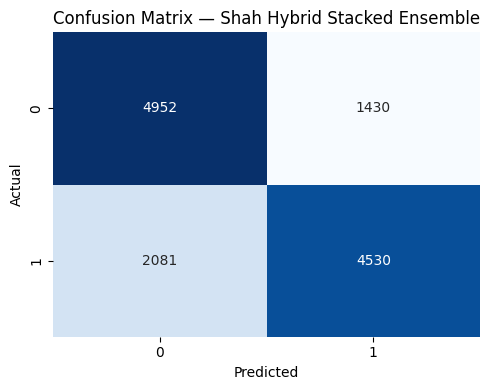

In [15]:
y_pred = best_full_model.predict(X_test)
y_proba = predict_positive_proba(best_full_model, X_test)

report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(TABLE_DIR / "classification_report_shah_hybrid.csv")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
pd.DataFrame(cm, index=["Actual_0", "Actual_1"], columns=["Pred_0", "Pred_1"]).to_csv(TABLE_DIR / "confusion_matrix_shah_hybrid.csv")

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix — Shah Hybrid Stacked Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
save_fig("confusion_matrix_shah_hybrid.png")
plt.show()

Saved figure: /kaggle/working/shah_2025_artifacts/figures/roc_curves_all_models.png


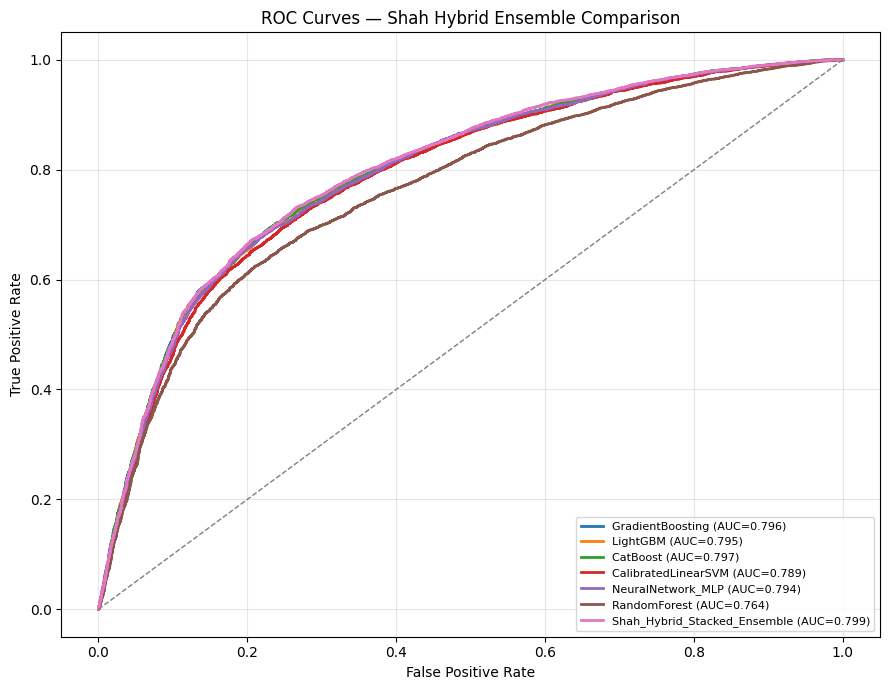

Saved figure: /kaggle/working/shah_2025_artifacts/figures/precision_recall_curves_all_models.png


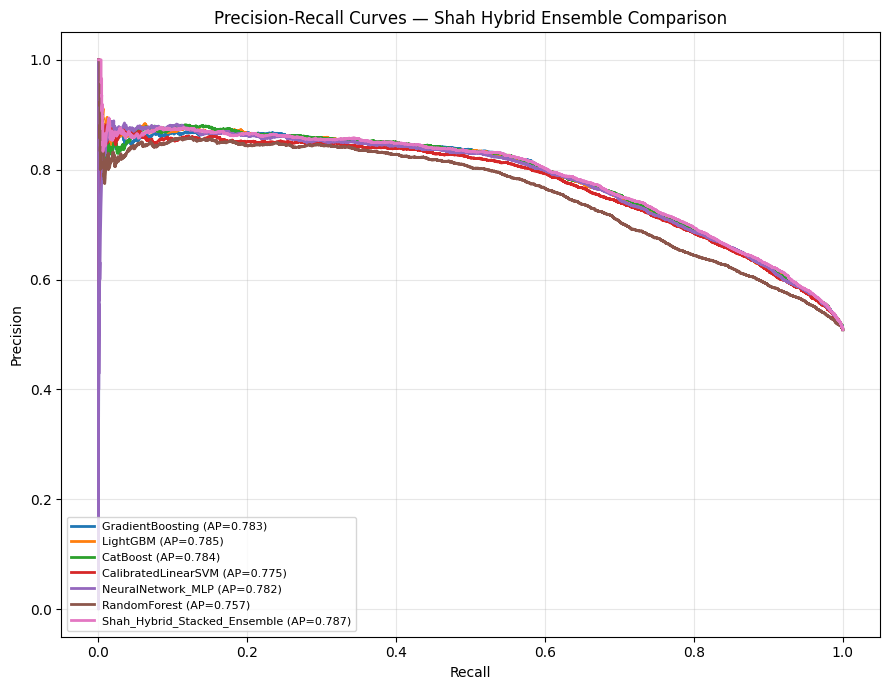

In [16]:
plt.figure(figsize=(9, 7))
for name, model in trained_models.items():
    proba = predict_positive_proba(model, X_test)
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "--", linewidth=1)
plt.title("ROC Curves — Shah Hybrid Ensemble Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
save_fig("roc_curves_all_models.png")
plt.show()

plt.figure(figsize=(9, 7))
for name, model in trained_models.items():
    proba = predict_positive_proba(model, X_test)
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})", linewidth=2)
plt.title("Precision-Recall Curves — Shah Hybrid Ensemble Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left", fontsize=8)
plt.grid(alpha=0.3)
save_fig("precision_recall_curves_all_models.png")
plt.show()

Saved figure: /kaggle/working/shah_2025_artifacts/figures/calibration_curve_shah_hybrid.png


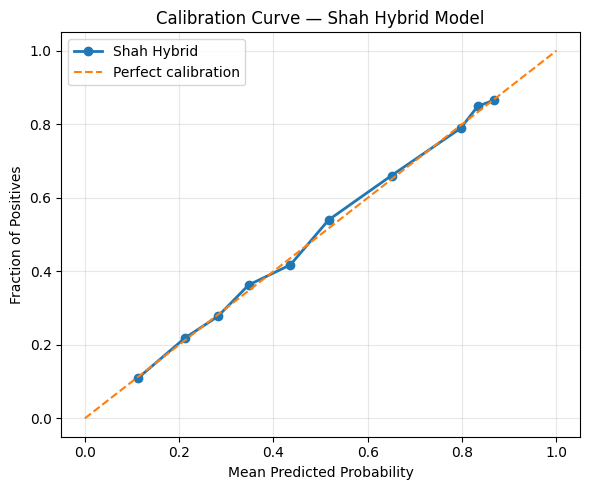

In [17]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")
calibration_df = pd.DataFrame({"mean_predicted_probability": prob_pred, "fraction_of_positives": prob_true})
calibration_df.to_csv(TABLE_DIR / "calibration_curve_shah_hybrid.csv", index=False)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", linewidth=2, label="Shah Hybrid")
plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
plt.title("Calibration Curve — Shah Hybrid Model")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend()
plt.grid(alpha=0.3)
save_fig("calibration_curve_shah_hybrid.png")
plt.show()

## 12. Explainability Technique 1 — SHAP global and local explanations

In [18]:
shap_background = shap.sample(X_train_balanced, min(SHAP_BACKGROUND_SIZE, len(X_train_balanced)), random_state=SEED)
shap_test_sample = shap.sample(X_test, min(XAI_SAMPLE_SIZE, len(X_test)), random_state=SEED)

print(f"SHAP background shape: {shap_background.shape}")
print(f"SHAP explanation sample shape: {shap_test_sample.shape}")


def shah_predict_proba_for_shap(data):
    data_df = pd.DataFrame(data, columns=feature_names)
    return best_full_model.predict_proba(data_df)

masker = shap.maskers.Independent(shap_background)
shap_explainer = shap.Explainer(shah_predict_proba_for_shap, masker, output_names=["No Disease", "Disease"])
max_evals = max(2 * len(feature_names) + 1, 101)
print(f"Using max_evals={max_evals} for SHAP explanations.")

shap_values_test = shap_explainer(shap_test_sample, max_evals=max_evals, batch_size=50)

if len(shap_values_test.values.shape) == 3:
    shap_matrix = shap_values_test.values[:, :, 1]
    base_values = shap_values_test.base_values[:, 1]
else:
    shap_matrix = shap_values_test.values
    base_values = shap_values_test.base_values

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP": np.abs(shap_matrix).mean(axis=0)
}).sort_values("MeanAbsSHAP", ascending=False)
shap_importance_df.to_csv(XAI_DIR / "shap_global_importance.csv", index=False)

display(shap_importance_df.head(15))

SHAP background shape: (120, 25)
SHAP explanation sample shape: (250, 25)
Using max_evals=101 for SHAP explanations.


PermutationExplainer explainer: 251it [02:34,  1.55it/s]                         


,Feature,MeanAbsSHAP
4,AP_HIGH,0.074114
24,SBP_CHOLESTEROL_INTERACTION,0.055118
16,MAP_ESTIMATE,0.030622
23,AGE_SBP_INTERACTION,0.029702
18,HYPERTENSION_FLAG,0.023805
22,AGE_BMI_INTERACTION,0.017070
0,AGE,0.012682
6,CHOLESTEROL,0.012660
10,PHYSICAL_ACTIVITY,0.011501
11,AGE_YEARS,0.009460


Saved figure: /kaggle/working/shah_2025_artifacts/figures/xai_shap_global_bar.png


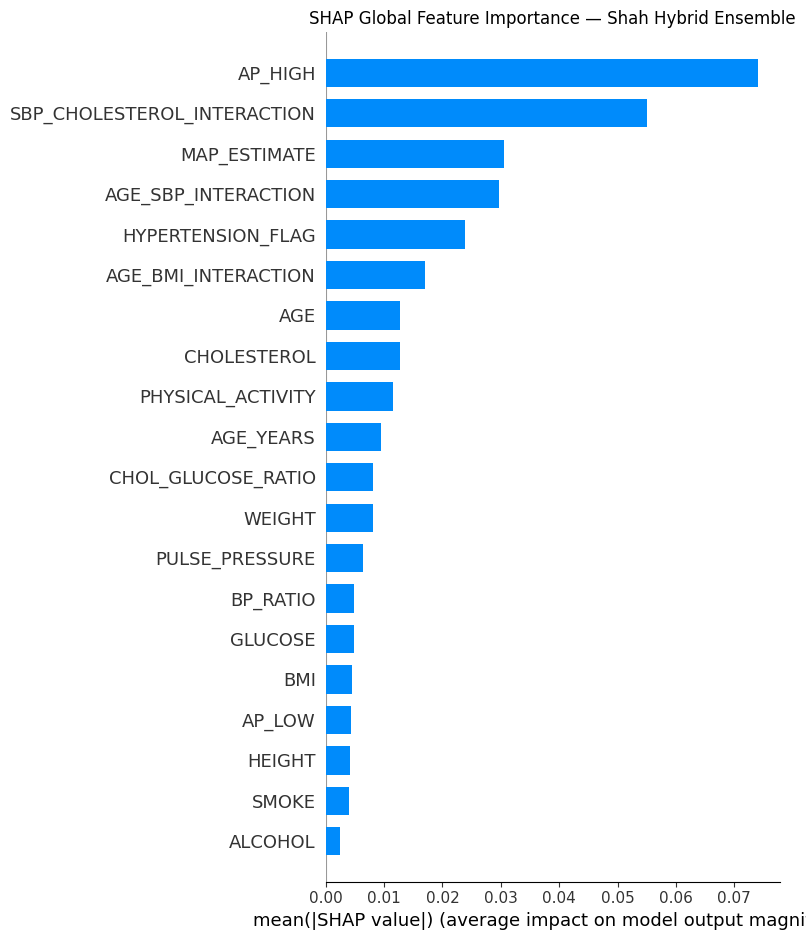

Saved figure: /kaggle/working/shah_2025_artifacts/figures/xai_shap_beeswarm.png


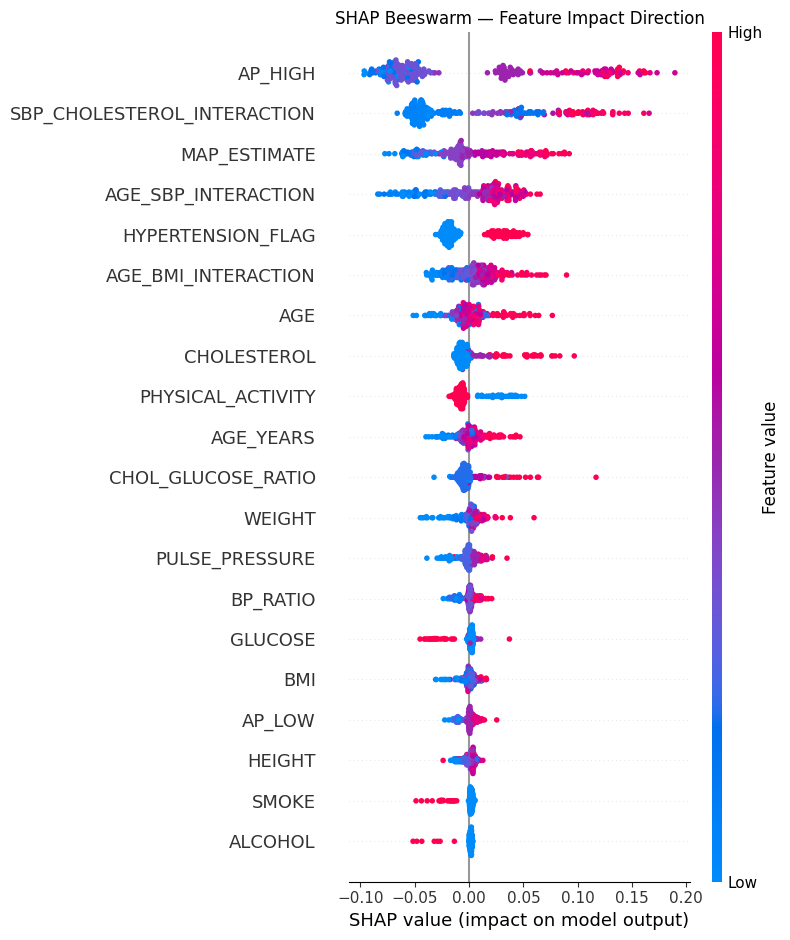

In [19]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_matrix, shap_test_sample, feature_names=feature_names, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Global Feature Importance — Shah Hybrid Ensemble")
save_fig("xai_shap_global_bar.png")
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_matrix, shap_test_sample, feature_names=feature_names, show=False, max_display=20)
plt.title("SHAP Beeswarm — Feature Impact Direction")
save_fig("xai_shap_beeswarm.png")
plt.show()

Saved figure: /kaggle/working/shah_2025_artifacts/figures/xai_shap_waterfall_positive_case.png


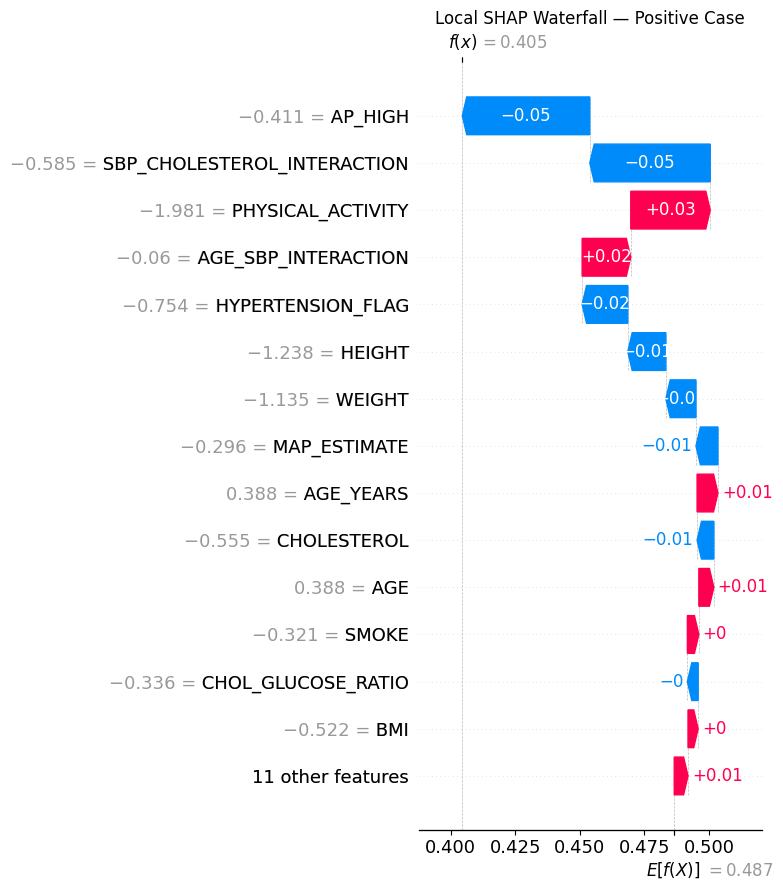

Saved figure: /kaggle/working/shah_2025_artifacts/figures/xai_shap_waterfall_negative_case.png


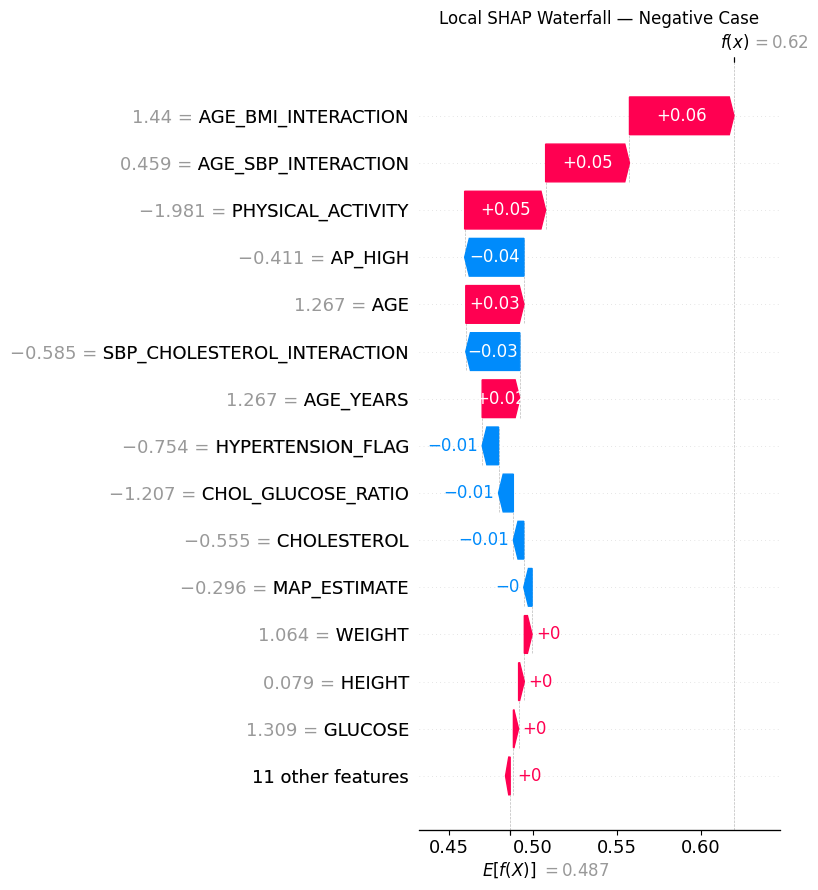

In [20]:
positive_positions = np.where(y_test.loc[shap_test_sample.index].values == 1)[0]
negative_positions = np.where(y_test.loc[shap_test_sample.index].values == 0)[0]

local_cases = []
if len(positive_positions) > 0:
    local_cases.append(("positive", int(positive_positions[0])))
if len(negative_positions) > 0:
    local_cases.append(("negative", int(negative_positions[0])))

for label, pos in local_cases:
    exp = shap.Explanation(
        values=shap_matrix[pos],
        base_values=base_values[pos] if np.ndim(base_values) > 0 else base_values,
        data=shap_test_sample.iloc[pos].values,
        feature_names=feature_names
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp, max_display=15, show=False)
    plt.title(f"Local SHAP Waterfall — {label.title()} Case")
    save_fig(f"xai_shap_waterfall_{label}_case.png")
    plt.show()

## 13. Explainability Technique 2 — LIME patient-level explanations

In [21]:
lime_background = X_train_balanced.sample(min(5000, len(X_train_balanced)), random_state=SEED)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=lime_background.values,
    feature_names=feature_names,
    class_names=["No Disease", "Disease"],
    mode="classification",
    discretize_continuous=True,
    random_state=SEED
)


def lime_predict_fn(data):
    data_df = pd.DataFrame(data, columns=feature_names)
    return best_full_model.predict_proba(data_df)

lime_rows = []
case_indices = []
positive_test_indices = y_test[y_test == 1].index.tolist()
negative_test_indices = y_test[y_test == 0].index.tolist()
if positive_test_indices:
    case_indices.append(("positive", positive_test_indices[0]))
if negative_test_indices:
    case_indices.append(("negative", negative_test_indices[0]))

for label, idx in case_indices:
    row = X_test.loc[idx].values
    exp = lime_explainer.explain_instance(
        data_row=row,
        predict_fn=lime_predict_fn,
        num_features=min(12, len(feature_names))
    )
    html_path = XAI_DIR / f"lime_explanation_{label}_case_{idx}.html"
    exp.save_to_file(str(html_path))
    print(f"Saved LIME explanation: {html_path}")

    for feature_rule, weight in exp.as_list():
        lime_rows.append({"case_type": label, "index": idx, "feature_rule": feature_rule, "lime_weight": weight})

lime_df = pd.DataFrame(lime_rows)
lime_df.to_csv(XAI_DIR / "lime_local_explanations.csv", index=False)
display(lime_df.head(20))

Saved LIME explanation: /kaggle/working/shah_2025_artifacts/xai_outputs/lime_explanation_positive_case_24599.html
Saved LIME explanation: /kaggle/working/shah_2025_artifacts/xai_outputs/lime_explanation_negative_case_80.html


,case_type,index,feature_rule,lime_weight
0,positive,24599,-0.41 < AP_HIGH <= 0.76,0.073907
1,positive,24599,ALCOHOL <= -0.25,0.056318
2,positive,24599,-0.75 < HYPERTENSION_FLAG <= 1.33,0.055066
3,positive,24599,-0.48 < SBP_CHOLESTEROL_INTERACTION <= 0.43,0.039356
4,positive,24599,SMOKE <= -0.32,0.034588
5,positive,24599,CHOLESTEROL <= -0.55,-0.031497
6,positive,24599,-0.06 < AGE_SBP_INTERACTION <= 0.61,0.026063
7,positive,24599,CHOL_GLUCOSE_RATIO <= -0.34,-0.020911
8,positive,24599,-0.79 < AGE <= 0.09,-0.018694
9,positive,24599,BP_RATIO > 0.39,0.016871


## 14. Explainability Technique 3 — Permutation importance

,Feature,ImportanceMean,ImportanceStd
4,AP_HIGH,0.028450,0.003918
24,SBP_CHOLESTEROL_INTERACTION,0.013249,0.001915
23,AGE_SBP_INTERACTION,0.013002,0.001717
16,MAP_ESTIMATE,0.009450,0.000961
22,AGE_BMI_INTERACTION,0.005711,0.001099
0,AGE,0.005402,0.000641
11,AGE_YEARS,0.003882,0.000250
3,WEIGHT,0.003012,0.000897
12,BMI,0.002872,0.000360
18,HYPERTENSION_FLAG,0.002620,0.000640


Saved figure: /kaggle/working/shah_2025_artifacts/figures/xai_permutation_importance.png


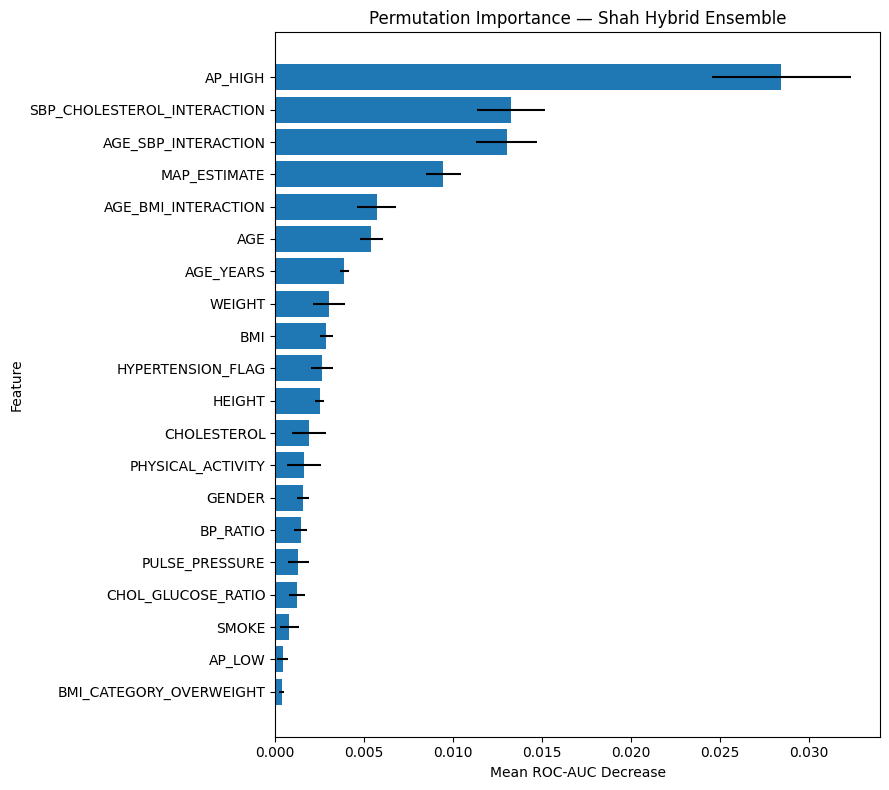

In [22]:
perm_X = X_test.sample(min(PERMUTATION_SAMPLE_SIZE, len(X_test)), random_state=SEED)
perm_y = y_test.loc[perm_X.index]

perm = permutation_importance(
    best_full_model,
    perm_X,
    perm_y,
    scoring="roc_auc",
    n_repeats=5 if not FAST_MODE else 3,
    random_state=SEED,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "ImportanceMean": perm.importances_mean,
    "ImportanceStd": perm.importances_std
}).sort_values("ImportanceMean", ascending=False)
perm_importance_df.to_csv(XAI_DIR / "permutation_importance.csv", index=False)

display(perm_importance_df.head(20))

plt.figure(figsize=(9, 8))
top_perm = perm_importance_df.head(20).iloc[::-1]
plt.barh(top_perm["Feature"], top_perm["ImportanceMean"], xerr=top_perm["ImportanceStd"])
plt.title("Permutation Importance — Shah Hybrid Ensemble")
plt.xlabel("Mean ROC-AUC Decrease")
plt.ylabel("Feature")
save_fig("xai_permutation_importance.png")
plt.show()

## 15. Explainability Technique 4 — PDP and ICE plots

PDP/ICE features: ['AP_HIGH', 'SBP_CHOLESTEROL_INTERACTION', 'AGE_SBP_INTERACTION', 'MAP_ESTIMATE']
Saved figure: /kaggle/working/shah_2025_artifacts/figures/xai_pdp_ice_AP_HIGH.png


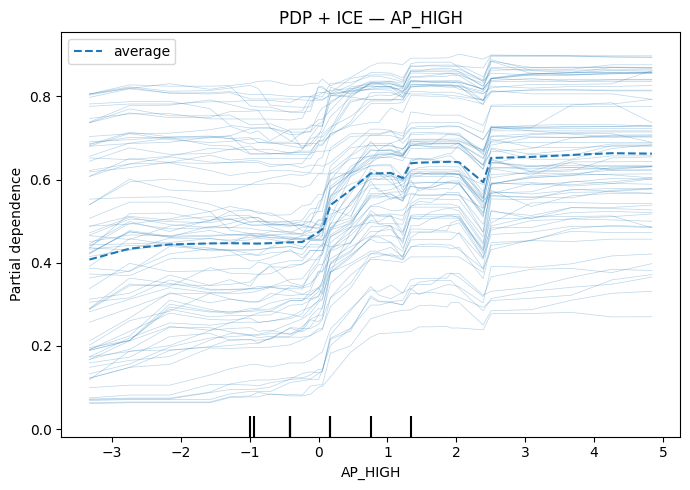

Saved figure: /kaggle/working/shah_2025_artifacts/figures/xai_pdp_ice_SBP_CHOLESTEROL_INTERACTION.png


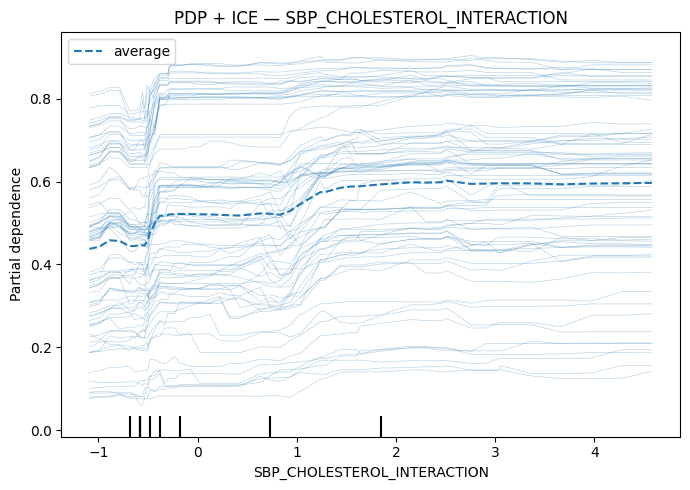

Saved figure: /kaggle/working/shah_2025_artifacts/figures/xai_pdp_ice_AGE_SBP_INTERACTION.png


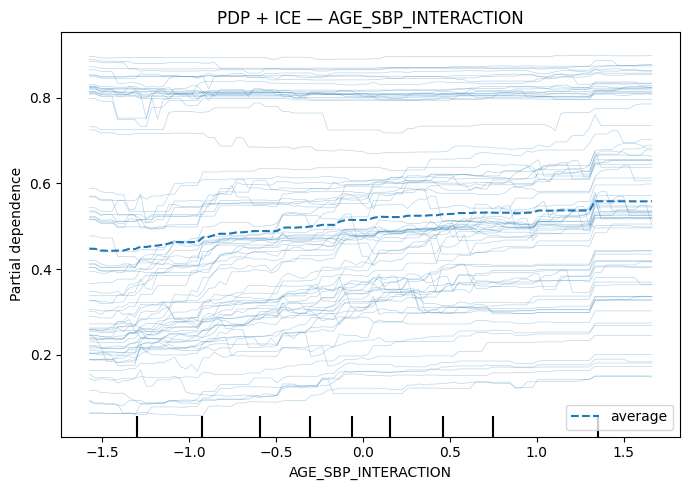

Saved figure: /kaggle/working/shah_2025_artifacts/figures/xai_pdp_ice_MAP_ESTIMATE.png


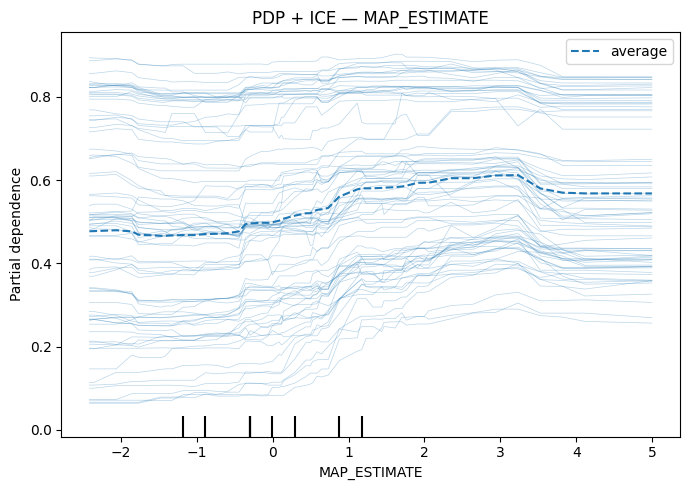

In [23]:
top_pdp_features = perm_importance_df["Feature"].head(min(4, len(feature_names))).tolist()
pdp_X = X_test.sample(min(1200, len(X_test)), random_state=SEED)
print("PDP/ICE features:", top_pdp_features)

for feature in top_pdp_features:
    fig, ax = plt.subplots(figsize=(7, 5))
    PartialDependenceDisplay.from_estimator(
        best_full_model,
        pdp_X,
        [feature],
        kind="both",
        subsample=80,
        random_state=SEED,
        ax=ax
    )
    plt.title(f"PDP + ICE — {feature}")
    save_fig(f"xai_pdp_ice_{feature}.png")
    plt.show()

## 16. Interpretability Technique 5 — PCA and t-SNE multidimensional risk maps

Saved figure: /kaggle/working/shah_2025_artifacts/figures/xai_pca_risk_projection.png


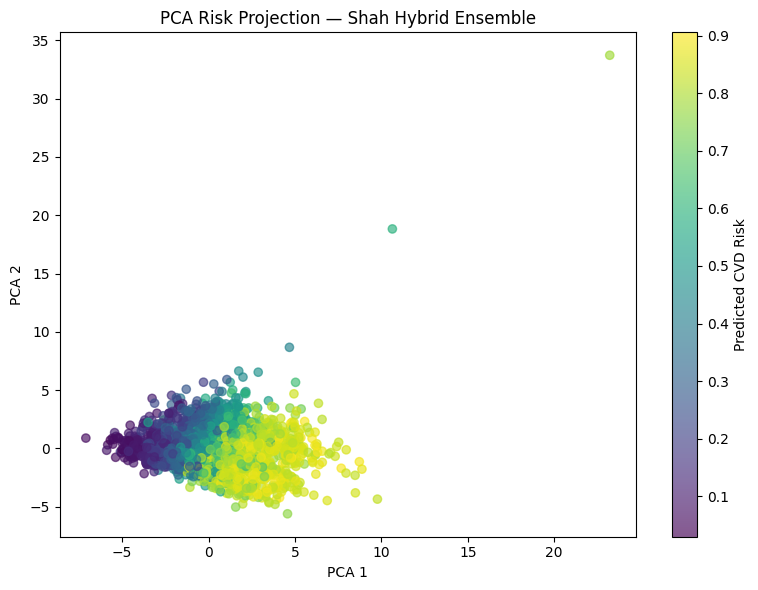

Saved figure: /kaggle/working/shah_2025_artifacts/figures/xai_tsne_risk_projection.png


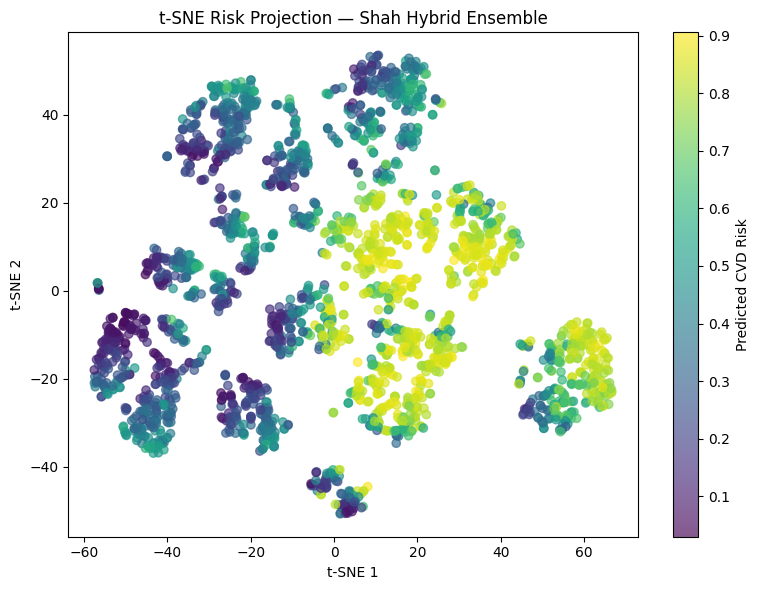

In [24]:
embed_X = X_test.sample(min(EMBEDDING_SAMPLE_SIZE, len(X_test)), random_state=SEED)
embed_y = y_test.loc[embed_X.index]
embed_proba = predict_positive_proba(best_full_model, embed_X)

pca = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(embed_X)
pca_df = pd.DataFrame({
    "PCA1": pca_coords[:, 0],
    "PCA2": pca_coords[:, 1],
    "true_label": embed_y.values,
    "predicted_risk": embed_proba
})
pca_df.to_csv(XAI_DIR / "pca_risk_projection.csv", index=False)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_df["PCA1"], pca_df["PCA2"], c=pca_df["predicted_risk"], alpha=0.65)
plt.colorbar(scatter, label="Predicted CVD Risk")
plt.title("PCA Risk Projection — Shah Hybrid Ensemble")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
save_fig("xai_pca_risk_projection.png")
plt.show()

tsne = TSNE(n_components=2, perplexity=min(30, max(5, len(embed_X)//50)), learning_rate="auto", init="pca", random_state=SEED)
tsne_coords = tsne.fit_transform(embed_X)
tsne_df = pd.DataFrame({
    "TSNE1": tsne_coords[:, 0],
    "TSNE2": tsne_coords[:, 1],
    "true_label": embed_y.values,
    "predicted_risk": embed_proba
})
tsne_df.to_csv(XAI_DIR / "tsne_risk_projection.csv", index=False)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_df["TSNE1"], tsne_df["TSNE2"], c=tsne_df["predicted_risk"], alpha=0.65)
plt.colorbar(scatter, label="Predicted CVD Risk")
plt.title("t-SNE Risk Projection — Shah Hybrid Ensemble")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
save_fig("xai_tsne_risk_projection.png")
plt.show()

## 17. Interpretability Technique 6 — Surrogate decision tree for model transparency

Surrogate fidelity: 0.9568
|--- AP_HIGH <= 0.08
|   |--- AGE_SBP_INTERACTION <= 0.35
|   |   |--- SBP_CHOLESTEROL_INTERACTION <= 0.68
|   |   |   |--- AGE_BMI_INTERACTION <= 1.07
|   |   |   |   |--- class: 0
|   |   |   |--- AGE_BMI_INTERACTION >  1.07
|   |   |   |   |--- class: 0
|   |   |--- SBP_CHOLESTEROL_INTERACTION >  0.68
|   |   |   |--- AGE_BMI_INTERACTION <= -0.36
|   |   |   |   |--- class: 0
|   |   |   |--- AGE_BMI_INTERACTION >  -0.36
|   |   |   |   |--- class: 1
|   |--- AGE_SBP_INTERACTION >  0.35
|   |   |--- WEIGHT <= -1.03
|   |   |   |--- class: 0
|   |   |--- WEIGHT >  -1.03
|   |   |   |--- AGE <= 1.19
|   |   |   |   |--- class: 1
|   |   |   |--- AGE >  1.19
|   |   |   |   |--- class: 1
|--- AP_HIGH >  0.08
|   |--- HYPERTENSION_FLAG <= 0.29
|   |   |--- SBP_CHOLESTEROL_INTERACTION <= -0.46
|   |   |   |--- AGE_YEARS <= 0.90
|   |   |   |   |--- class: 0
|   |   |   |--- AGE_YEARS >  0.90
|   |   |   |   |--- class: 1
|   |   |--- SBP_CHOLESTEROL_INTERACTION

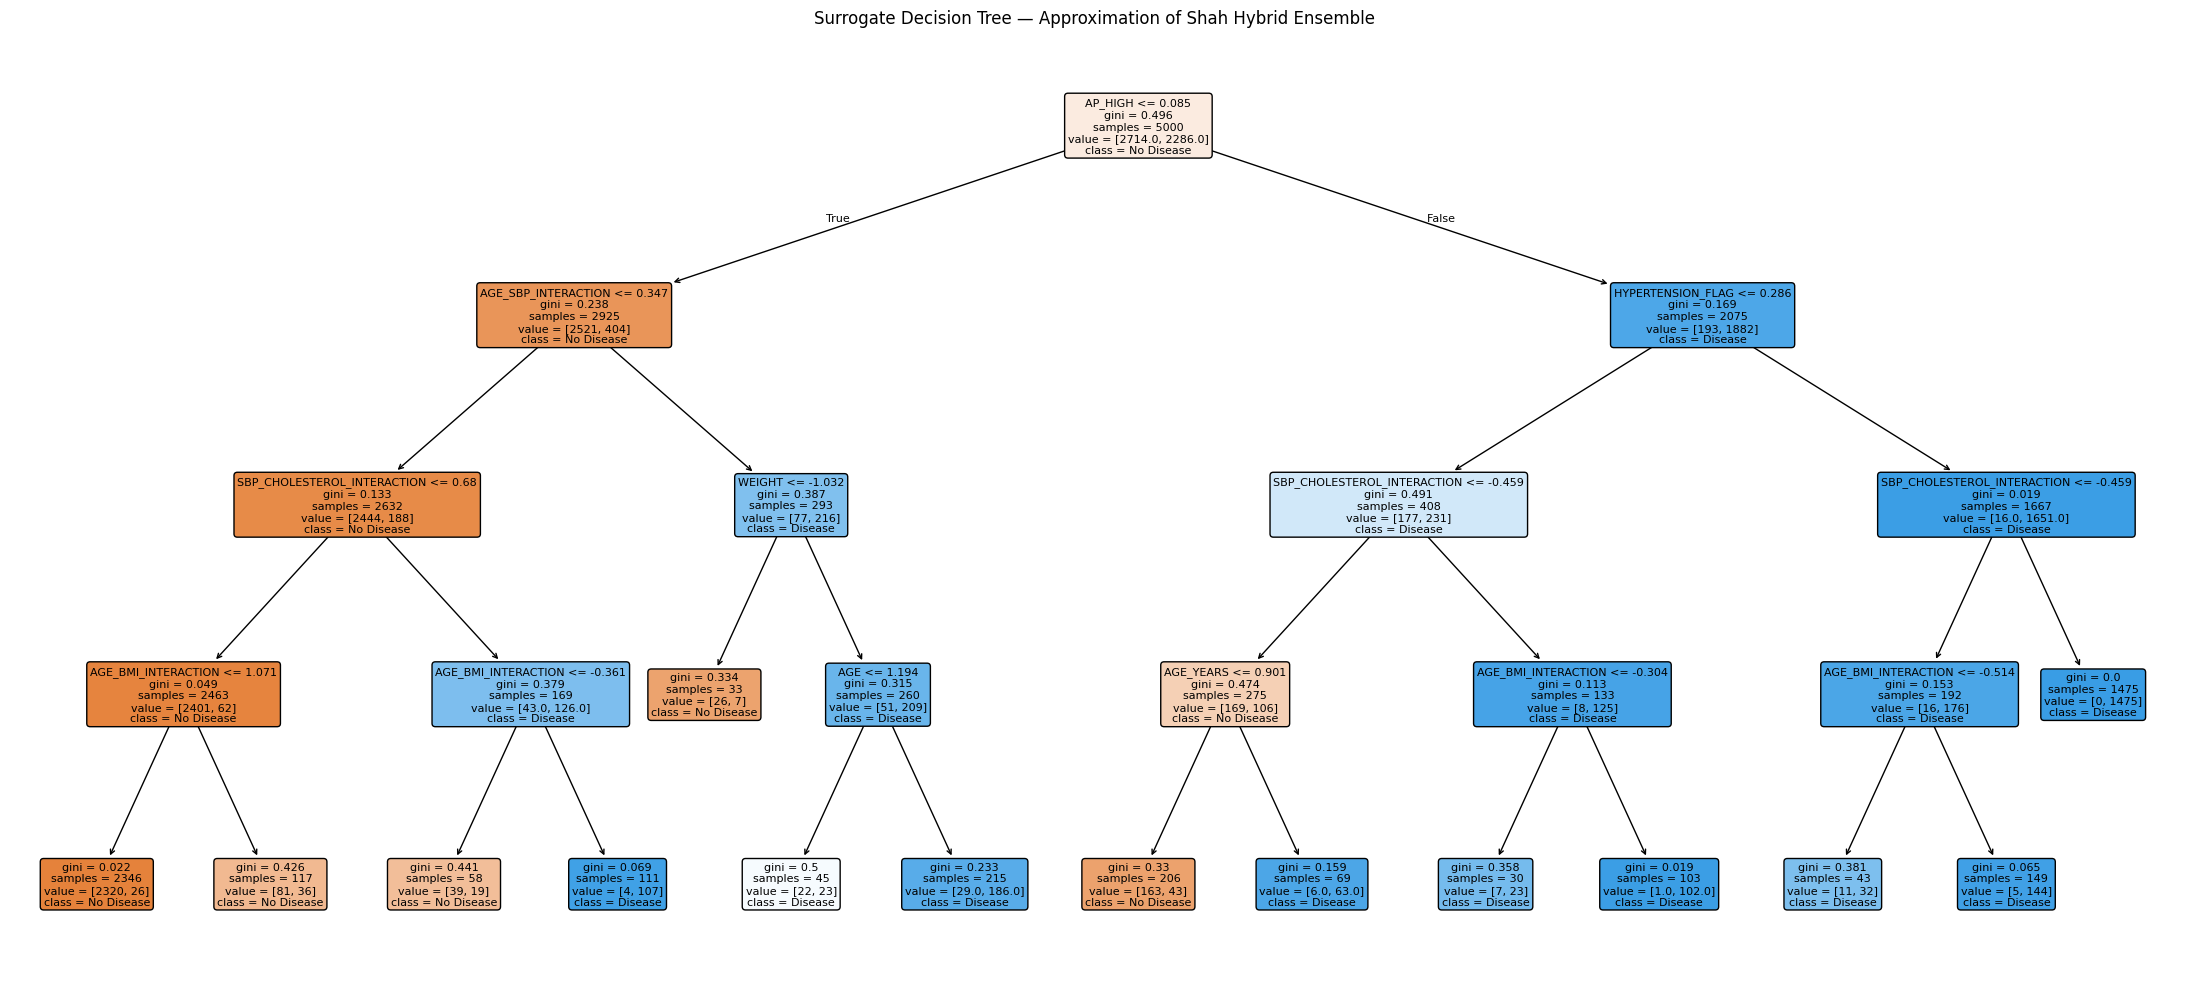

In [25]:
surrogate_X = X_test.sample(min(5000, len(X_test)), random_state=SEED)
surrogate_y = best_full_model.predict(surrogate_X)

surrogate_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=SEED)
surrogate_tree.fit(surrogate_X, surrogate_y)
surrogate_pred = surrogate_tree.predict(surrogate_X)
surrogate_fidelity = accuracy_score(surrogate_y, surrogate_pred)

rules = export_text(surrogate_tree, feature_names=feature_names, max_depth=4)
with open(XAI_DIR / "surrogate_decision_tree_rules.txt", "w") as f:
    f.write(f"Surrogate fidelity to Shah Hybrid Ensemble: {surrogate_fidelity:.4f}\n\n")
    f.write(rules)

print(f"Surrogate fidelity: {surrogate_fidelity:.4f}")
print(rules[:4000])

plt.figure(figsize=(22, 10))
plot_tree(
    surrogate_tree,
    feature_names=feature_names,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Surrogate Decision Tree — Approximation of Shah Hybrid Ensemble")
save_fig("xai_surrogate_decision_tree.png")
plt.show()

## 18. Cross-XAI agreement analysis

,Feature,SHAP_Rank,Permutation_Rank,RF_Rank,Mean_Rank,Rank_Std
5,AP_HIGH,1.0,1.0,3.0,1.666667,1.154701
22,SBP_CHOLESTEROL_INTERACTION,2.0,2.0,7.0,3.666667,2.886751
1,AGE_BMI_INTERACTION,6.0,5.0,1.0,4.000000,2.645751
2,AGE_SBP_INTERACTION,4.0,3.0,6.0,4.333333,1.527525
19,MAP_ESTIMATE,3.0,4.0,8.0,5.000000,2.645751
0,AGE,7.0,6.0,10.0,7.666667,2.081666
24,WEIGHT,12.0,8.0,4.0,8.000000,4.000000
3,AGE_YEARS,10.0,7.0,9.0,8.666667,1.527525
17,HYPERTENSION_FLAG,5.0,10.0,11.0,8.666667,3.214550
7,BMI,16.0,9.0,2.0,9.000000,7.000000


Saved figure: /kaggle/working/shah_2025_artifacts/figures/xai_cross_method_agreement.png


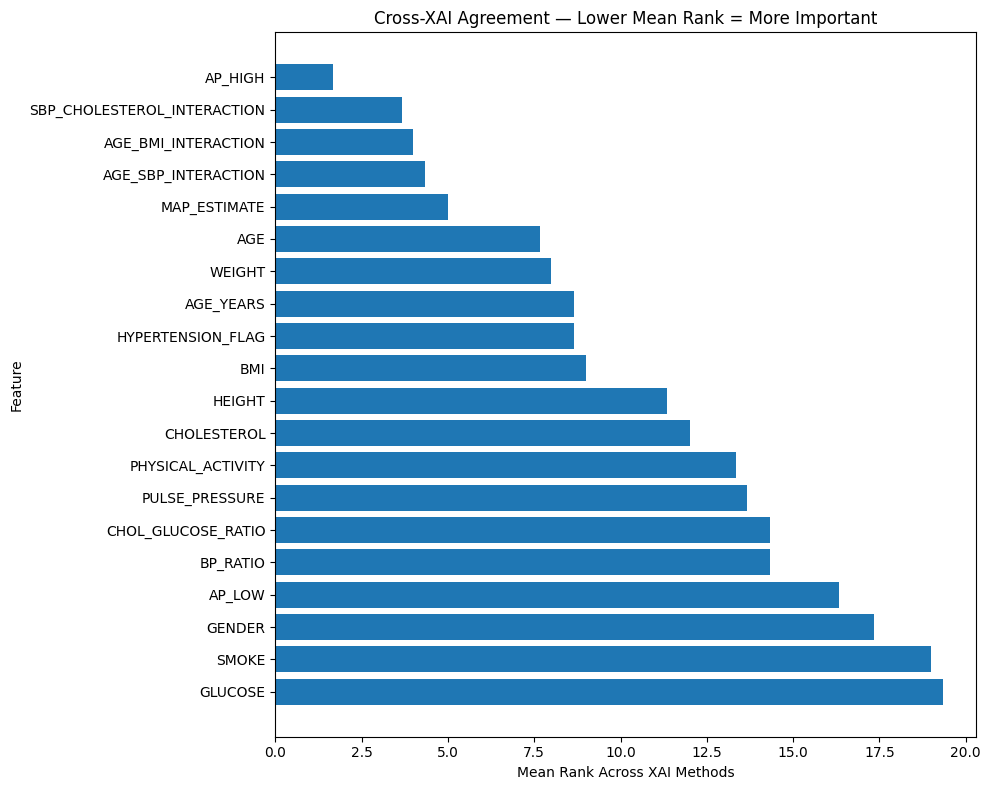

In [26]:
rank_frames = []

shap_rank = shap_importance_df.copy()
shap_rank["SHAP_Rank"] = shap_rank["MeanAbsSHAP"].rank(ascending=False, method="min")
rank_frames.append(shap_rank[["Feature", "SHAP_Rank"]])

perm_rank = perm_importance_df.copy()
perm_rank["Permutation_Rank"] = perm_rank["ImportanceMean"].rank(ascending=False, method="min")
rank_frames.append(perm_rank[["Feature", "Permutation_Rank"]])

if "RandomForest" in trained_models and hasattr(trained_models["RandomForest"], "feature_importances_"):
    rf_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "RFImportance": trained_models["RandomForest"].feature_importances_
    }).sort_values("RFImportance", ascending=False)
    rf_importance_df["RF_Rank"] = rf_importance_df["RFImportance"].rank(ascending=False, method="min")
    rf_importance_df.to_csv(XAI_DIR / "random_forest_builtin_importance.csv", index=False)
    rank_frames.append(rf_importance_df[["Feature", "RF_Rank"]])

agreement_df = rank_frames[0]
for frame in rank_frames[1:]:
    agreement_df = agreement_df.merge(frame, on="Feature", how="outer")

rank_cols = [c for c in agreement_df.columns if c.endswith("_Rank")]
agreement_df["Mean_Rank"] = agreement_df[rank_cols].mean(axis=1)
agreement_df["Rank_Std"] = agreement_df[rank_cols].std(axis=1)
agreement_df = agreement_df.sort_values("Mean_Rank")
agreement_df.to_csv(XAI_DIR / "cross_xai_feature_ranking_agreement.csv", index=False)

display(agreement_df.head(20))

plt.figure(figsize=(10, 8))
plot_agreement = agreement_df.head(20).iloc[::-1]
plt.barh(plot_agreement["Feature"], plot_agreement["Mean_Rank"])
plt.title("Cross-XAI Agreement — Lower Mean Rank = More Important")
plt.xlabel("Mean Rank Across XAI Methods")
plt.ylabel("Feature")
save_fig("xai_cross_method_agreement.png")
plt.show()

## 19. Clinical interpretation summary

In [27]:
top_features = agreement_df.head(10)["Feature"].tolist()
clinical_summary_rows = []

for feature in top_features:
    row = {"Feature": feature}
    if feature in shap_importance_df["Feature"].values:
        row["SHAP_MeanAbs"] = float(shap_importance_df.loc[shap_importance_df["Feature"] == feature, "MeanAbsSHAP"].iloc[0])
    if feature in perm_importance_df["Feature"].values:
        row["Permutation_Importance"] = float(perm_importance_df.loc[perm_importance_df["Feature"] == feature, "ImportanceMean"].iloc[0])
    row["Clinical_Interpretation_Note"] = (
        "Higher influence on predicted cardiovascular risk according to multiple XAI methods. "
        "Review directionality using SHAP beeswarm/PDP before clinical discussion."
    )
    clinical_summary_rows.append(row)

clinical_summary_df = pd.DataFrame(clinical_summary_rows)
clinical_summary_df.to_csv(XAI_DIR / "clinical_interpretation_summary.csv", index=False)
display(clinical_summary_df)

,Feature,SHAP_MeanAbs,Permutation_Importance,Clinical_Interpretation_Note
0,AP_HIGH,0.074114,0.028450,Higher influence on predicted cardiovascular r...
1,SBP_CHOLESTEROL_INTERACTION,0.055118,0.013249,Higher influence on predicted cardiovascular r...
2,AGE_BMI_INTERACTION,0.017070,0.005711,Higher influence on predicted cardiovascular r...
3,AGE_SBP_INTERACTION,0.029702,0.013002,Higher influence on predicted cardiovascular r...
4,MAP_ESTIMATE,0.030622,0.009450,Higher influence on predicted cardiovascular r...
5,AGE,0.012682,0.005402,Higher influence on predicted cardiovascular r...
6,WEIGHT,0.008043,0.003012,Higher influence on predicted cardiovascular r...
7,AGE_YEARS,0.009460,0.003882,Higher influence on predicted cardiovascular r...
8,HYPERTENSION_FLAG,0.023805,0.002620,Higher influence on predicted cardiovascular r...
9,BMI,0.004467,0.002872,Higher influence on predicted cardiovascular r...


## 20. Save all artifacts 

In [28]:
joblib.dump(preprocessor, MODEL_DIR / "preprocessor.joblib")
joblib.dump(best_full_model, MODEL_DIR / "shah_hybrid_stacked_ensemble.joblib")
joblib.dump(trained_models, MODEL_DIR / "all_trained_models.joblib")
joblib.dump(surrogate_tree, MODEL_DIR / "surrogate_decision_tree.joblib")

with open(OUTPUT_DIR / "feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

summary = {
    "project": PROJECT_NAME,
    "paper": "Shah et al. (2025) - Predicting cardiovascular risk with hybrid ensemble learning and explainable AI",
    "dataset_path": str(DATA_PATH),
    "target_column": TARGET_COLUMN,
    "raw_shape": list(df_raw.shape),
    "clean_shape": list(df.shape),
    "feature_engineered_shape": list(df_fe.shape),
    "train_shape": list(X_train.shape),
    "test_shape": list(X_test.shape),
    "balanced_train_shape": list(X_train_balanced.shape),
    "balancing_method": balancing_method,
    "primary_model": "Shah_Hybrid_Stacked_Ensemble",
    "base_models": list(base_models.keys()),
    "meta_learner": "XGBoost",
    "best_model_by_roc_auc": str(best_model_name),
    "primary_model_metrics": results_df.loc[results_df["Model"] == "Shah_Hybrid_Stacked_Ensemble"].to_dict(orient="records"),
    "xai_methods": [
        "SHAP global and local explanations",
        "LIME local explanations",
        "Permutation importance",
        "PDP and ICE",
        "PCA/t-SNE multidimensional risk maps",
        "Surrogate decision tree",
        "Cross-XAI agreement analysis"
    ],
    "created_at": datetime.now().isoformat()
}
with open(OUTPUT_DIR / "experiment_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

artifact_files = []
for path in OUTPUT_DIR.rglob("*"):
    if path.is_file():
        artifact_files.append({
            "relative_path": str(path.relative_to(OUTPUT_DIR)),
            "size_kb": round(path.stat().st_size / 1024, 2)
        })
manifest_df = pd.DataFrame(artifact_files).sort_values("relative_path")
manifest_df.to_csv(OUTPUT_DIR / "artifact_manifest.csv", index=False)
display(manifest_df)

zip_base = OUTPUT_DIR.parent / "Shah_2025_Hybrid_Ensemble_XAI_Artifacts"
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=OUTPUT_DIR)
print(f"All artifacts saved in: {OUTPUT_DIR.resolve()}")
print(f"Artifacts ZIP created at: {zip_path}")

,relative_path,size_kb
0,experiment_summary.json,1.62
1,feature_names.json,0.44
29,figures/calibration_curve_shah_hybrid.png,60.51
24,figures/confusion_matrix_shah_hybrid.png,24.74
26,figures/eda_class_distribution.png,34.36
18,figures/eda_correlation_heatmap.png,87.91
36,figures/eda_numeric_distributions.png,316.77
27,figures/precision_recall_curves_all_models.png,119.36
19,figures/roc_curves_all_models.png,138.70
25,figures/xai_cross_method_agreement.png,91.07


All artifacts saved in: /kaggle/working/shah_2025_artifacts
Artifacts ZIP created at: /kaggle/working/Shah_2025_Hybrid_Ensemble_XAI_Artifacts.zip
